#### Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss

#### Import Libraries

In [4]:
df = pd.read_csv('KNNAlgorithmDataset.csv')

In [5]:
print(df.shape)

(569, 33)


In [6]:
print(df.head(5))

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

#### Drop Unnecessary Columns

In [12]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [13]:
print(df.shape)

(569, 31)


#### Check Missing Values

In [14]:
print( df.isnull().values.any())

False


#### Encode Target and Define Features

In [15]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # Malignant = 1, Benign = 0

X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

#### Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature Scaling

In [17]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### Scratch KNN Classifier Implementation

In [25]:
class ScratchKNNClassifier:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _compute_distances(self, X):
        # Euclidean distance formula calculation
        return np.sqrt(np.sum((X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) ** 2, axis=2))

    def predict(self, X):
        distances = self._compute_distances(X)
        predictions = []
        for row_dist in distances:
            nearest_indices = np.argsort(row_dist)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            # Majority vote
            most_common = Counter(nearest_labels).most_common(1)
            predictions.append(most_common[0][0])
        return np.array(predictions)

    def predict_proba(self, X):
        distances = self._compute_distances(X)
        probas = []
        for row_dist in distances:
            nearest_indices = np.argsort(row_dist)[:self.k]
            nearest_labels = self.y_train[nearest_indices]
            prob_1 = np.sum(nearest_labels == 1) / self.k
            probas.append([1 - prob_1, prob_1])
        return np.array(probas)

#### Train and Predict

In [26]:
knn_clf = ScratchKNNClassifier(k=5)
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)

#### Calculate Metrics

In [27]:
accuracy = np.mean(y_pred == y_test) * 100
mse = np.mean((y_test - y_pred) ** 2)
loss = log_loss(y_test, knn_clf.predict_proba(X_test))

#### Evaluation Results

In [28]:
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Log Loss: {loss:.4f}")

Test Accuracy: 94.74%
Mean Squared Error: 0.0526
Log Loss: 0.3981


#### Target Variable Distribution

C:\Users\saher\AppData\Local\Temp\ipykernel_9960\1682870738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


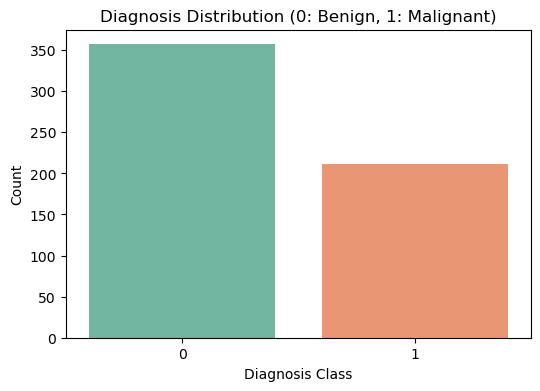

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="Set2")
plt.title("Diagnosis Distribution (0: Benign, 1: Malignant)")
plt.xlabel("Diagnosis Class")
plt.ylabel("Count")
plt.show()

#### KNN Accuracy Across Different K Values

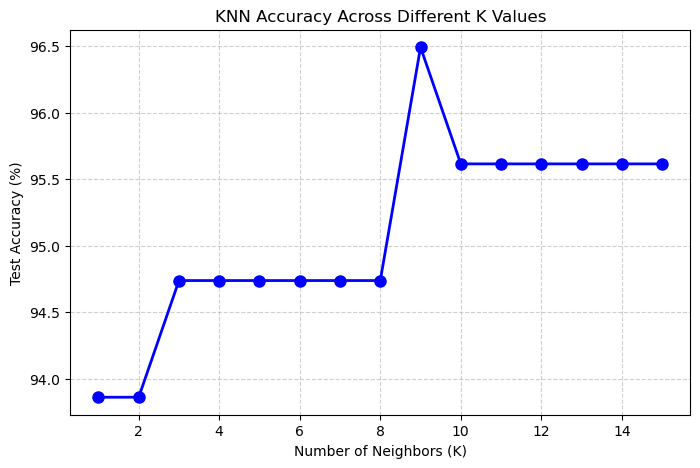

In [30]:
k_values = range(1, 16)
accuracies = []
for k in k_values:
  knn = ScratchKNNClassifier(k=k)
  knn.fit(X_train, y_train)
  y_pred_k = knn.predict(X_test)
  acc = np.mean(y_pred_k == y_test) * 100
  accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    accuracies,
    marker="o",
    linestyle="-",
    color="b",
    linewidth=2,
    markersize=8,
)
plt.title("KNN Accuracy Across Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

#### Feature Scatter Plot (Radius Mean vs Texture Mean)

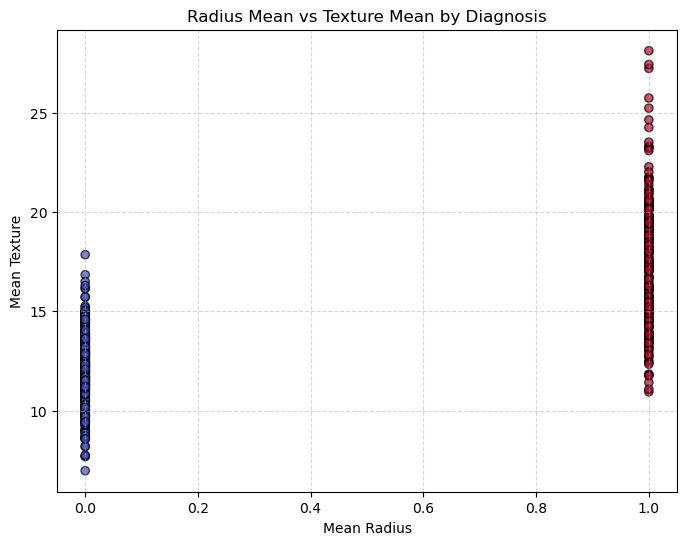

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df.iloc[:, 0], df.iloc[:, 1], c=y, cmap="coolwarm", alpha=0.7, edgecolor="k"
)
plt.title("Radius Mean vs Texture Mean by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()